# Student name: Gabriel Espinoza Rojas

# Student ID: 22176691

## Please do not add further imports. If you think an import is missing, please contact your moderator.

The notebook provides empty cells for your answer to give you guidance on the answer expected from you. You may add cells, but please note this may mean you go beyond what is expected from you and, if this results in unnecessary/unrelated content being added, may reduce your grade.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random

from sklearn import preprocessing
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.neural_network import MLPClassifier

# Task 1
Describe (in a markdown cell; max 500 words) how a perceptron can be used to classify two objects given their circumference and weight. You may assume that these two features result in linear separability of the two classes in the given dataset. Use the following terms in your description:

1. Input space
2. Output space
3. Unknown target function
4. Data set
5. Hypothesis set
6. Final Hypothesis
7. Error measure
8. In-sample error
9. Out-of-sample error

## Task 1 Answer



<!--should I explain that we add an extra 'feature' that is just '1' to the features?-->

A Perceptron is a Learning Algorithm, this is why often in literature is abbreviated as 'PLA'. For this classification problem it could be used in conjunction with a <b>hypothesis set</b> in the linear space to learn from data how to recognise two objects. When you combine a learning algorithm with a hypothesis set, this is called 'a learning model'. 

With an <b>input space</b> of N-samples with features: <u>circumference</u> and <u>weight</u>, an <b>unknown target function</b> could be for example 'is the object a ball or a pencil?' and, of course, no mathematical function could perfectly describe this phenomenon, since just mapping all possible pencils and balls in the universe is virtually impossible, therefore, the target function is literally unknown. But is this exactly why problems like this one can be solve with machine learning. The perceptron will learn from the training data, and in this situation, where linear separability is guaranteed, it will converge to total classification. Training data goes beyond describing the object, but it also brings its classification, so the learning model will know when misclassification has occurred.

An interesting fact about the PLA, is that despite its classification power, it only ever uses one misclassified point at the time to formulate a new hypothesis. The perceptron takes the <b>data set</b> to performance linear classification over it until reaching a <b>final hypothesis</b>, that is the hypothesis that correctly classifies all objects as either a ball or a pencil. This last hypothesis gets as close as possible to what the unknown target function maps that results on the <b>output space</b>. The perceptron usually start with a poor hypothesis (random or zero values) and take a single misclassified point in the data set to come up with a new (and hopefully better) hypothesis.

In the context of linear separability, this can be thought as the perceptron starting from an arbitrary lane and nudging it as it goes through the <b>hypothesis set</b> until a line that separates the two classes is found (<b>final hypothesis</b>). After every line/hypothesis, the mean squared root error is used as the <b>error measure</b>, if the last line drew already leads to no objects misclassified, this becomes the <b>final Hypothesis</b>. 

The <b>in-sample error</b> will be the error related to the objects used to reach the <b>final hypothesis</b>, and the <b>out-of-sample</b> error is related to effectiveness of the perceptron to classify previously unseen objects. For both of this cases, the mean squared error is used as the <b>error measure</b>.

The <b>output space</b> for this perceptron will be a plane were all objects are either under or over the final hypothesis line. In numerical terms, this means that every object would be assigned to a value that would map to the class 'ball' or 'pencil', or example 1 and -1.


___

# Task 2
## Task 2 code

In [14]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Error")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_errors = 1- train_scores
    test_errors = 1-test_scores
    
    train_errors_mean = np.mean(train_errors, axis=1)
    train_errors_std = np.std(train_errors, axis=1)
    test_errors_mean = np.mean(test_errors, axis=1)
    test_errors_std = np.std(test_errors, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                     train_errors_mean + train_errors_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                     test_errors_mean + test_errors_std, alpha=0.1, color="b")
    plt.plot(train_sizes, train_errors_mean, 'o-', color="r",
             label="Training error")
    plt.plot(train_sizes, test_errors_mean, 'o-', color="b",
             label="Test error")

    
    plt.legend(loc="best")
    return plt

In [15]:
data = np.loadtxt("Et1_Task2.csv", delimiter=",")
X = data[:,0:2]
y=data[:,2]

### Logistic regression learning curve

In [16]:
cv = ShuffleSplit(n_splits=25, test_size=0.2)

<module 'matplotlib.pyplot' from 'c:\\Users\\Admin\\Documents\\UL\\master\\CE6002 - Artificial Intelligence and Machine Learning\\e-tivity1\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

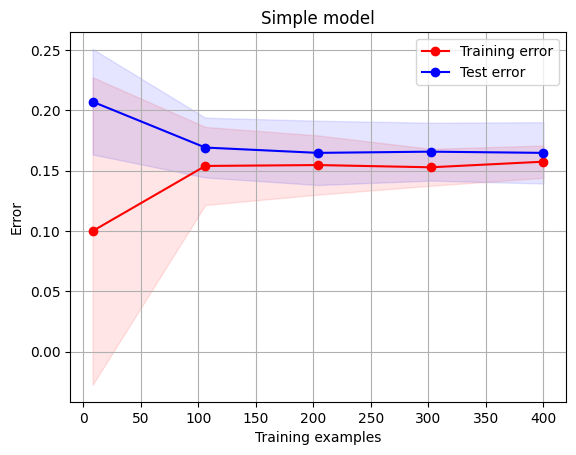

In [17]:
estimator = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial')
plot_learning_curve(estimator, "Simple model", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5))

### Neural net learning curves

<module 'matplotlib.pyplot' from 'c:\\Users\\Admin\\Documents\\UL\\master\\CE6002 - Artificial Intelligence and Machine Learning\\e-tivity1\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

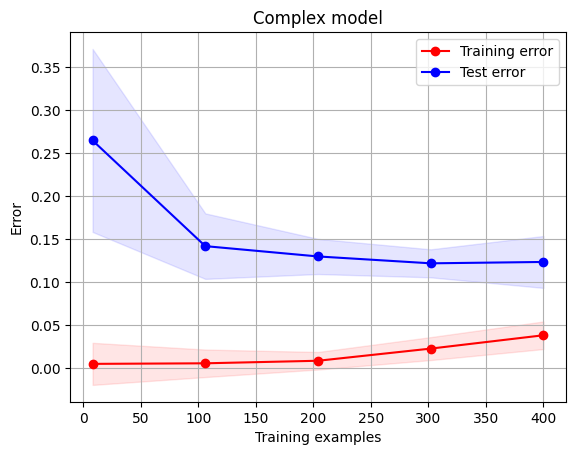

In [18]:
estimator = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(200, 4), random_state=1)
plot_learning_curve(estimator, "Complex model", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5))

<module 'matplotlib.pyplot' from 'c:\\Users\\Admin\\Documents\\UL\\master\\CE6002 - Artificial Intelligence and Machine Learning\\e-tivity1\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

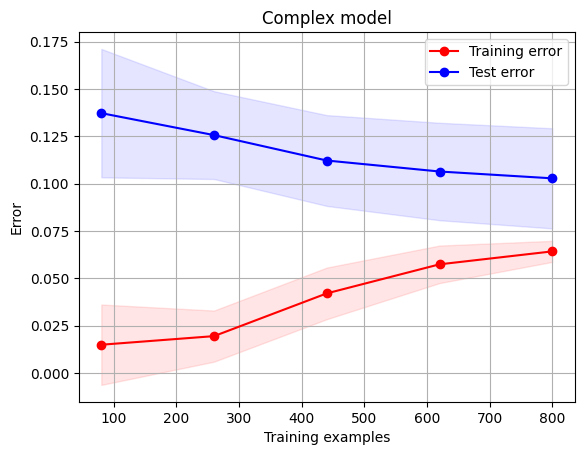

In [19]:
estimator = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(200, 4), random_state=1)
plot_learning_curve(estimator, "Complex model", X, y, cv=cv, n_jobs=4)

## Task 2 Instructions
Run the code (or observe the provided outputs) in the E-tivity notebook under Task 2. This code implements so-called learning curves that plot the performance of a model (both in-sample as well as out-of-sample) as this model is trained with an increasing number of data points. Observe the plots and answer the following questions (max of 150 words per answer):

1. Describe what is displayed in the learning curves.
2. Explain why the training error is (generally) lower than the test error
3. Explain  why the training error increases as the number of training samples is increased
4. Explain which of the two models is the more complex model judged by the learning curves

## Task 2 Answer


1. Describe what is displayed in the learning curves.

The learning curves display the average output (continuous line) and the variance in the output (faded space) for the $E_{in}$ (in-sample error, also known as training error) and $E_{out}$ (out-of-sample error, also know as testing error) values. They also tell us about the complexity of the model by if one analyses the converge point and the relationship between the in-sample and out-of-sample error.

2. Explain why the training error is (generally) lower than the test error

Because the training error (in-sample error) measures how well the final hypothesis fits the data set used to trained the model, the test error (out-of-sample error) will always be unknown and the hope is that the $E_{in}$ can track it well. 

3. Explain  why the training error increases as the number of training samples is increased

This is due to the fact that any model will be able to approximate a limited number of samples better than a larger number of samples. So much that complex models can experience zero training error when the number of training examples is small. But this only means that the model has essentially memorised the 'correct answers' instead of learning. 

4. Explain which of the two models is the more complex model judged by the learning curves

The second model is more complex. The first plot (logistic regression) shows that while learning, the $E_{in}$ stays very close to the $E_{out}$ ($\approx$ 0.02) and both converge at an asymptote value higher ($\approx$ 0.16) than the second Model. The second model (Multi-Layer Perceptron) starts with a $E_{in}$ almost at zero (basically, the model memorises the whole sample) and as the data set increases, the $E_{in}$ increases but the $E_{out}$ decreases considerably, going from $\approx 0.25$ to $\approx 0.10$ with $400$ samples and from $\approx 0.125$ to $\approx 0.100$ with $800$ samples. 

<!-- 4 - Explain which of the two models is the more complex model judged by the learning curves
First model: "is too simple as the asymptote that the E_out and E_in both converge to, lies at quite a high level" -->

___

# Task 3 
## Task 3 code

Below functions implement linear regression and linear classification in a closed form (one-step solution using the pseudo-inverse).

In [20]:
def linreg_weights(X,y):
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    # Calculation of weights using pseudo-inverse.
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [21]:
def linreg_predict(w,X):
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

## Task 3 Instructions
In this task we will explore squared error as an objective function in linear regression. We will also explore the impact of outliers on this error function.

Use the code provided in the E-tivity notebook under Task 3 to implement a linear regression algorithm trained on dataset Et1_Task3.csv.

1. Add a function implementing the error function used in linear regression.
2. Provide a mathematical function of the regression lines in terms of the weights found by the linear regression algorithm. This does not need to be a a Python function; use of Latex in a markdown cell would be useful.
3. Plot the regression line together with the data and quantify the absolute error across all data points. The absolute error for a data point x with real value y and predicted value yp is defined as: $e_{abs}=\vert y - y_p\vert$
4. Add one data point to the dataset to illustrate how linear regression responds to outliers. Ensure that the absolute error that this new point contributes is no bigger than the sum of absolute errors contributed by all other points.
5. In a new plot, plot the data, the regression line obtained without, and the regression line obtained with the extra data point.
6. Answer the following questions (max 100 words per answer):
    1. Describe what linear regression tries to achieve in deciding on a regression line/function.
    2. Explain why one outlier with an absolute error no bigger than the combined absolute error of all other data points can have such a big impact on the regression line.

## Task 3 Answer
We suggest to stick to the number of cells provided below.

### 1. Add a function implementing the error function used in linear regression.

In [22]:
"""Unlike the classification case, in which we could take the ratio of misclassified points to all points
as our error, in regression we cannot do this, as the error is no longer binary."""

""" the square error summed across all training data points is used"""

def ligreg_error(y, y_p):

    """mean square error"""

    N = len(y)
    sum_square_err = 0
    for i in range(N):
        sum_square_err = sum_square_err + (y[i] - y_p[i])**2

    return sum_square_err/N

### 2. Provide a mathematical function of the regression lines in terms of the weights found by the linear regression algorithm. This does not need to be a a Python function; use of Latex in a markdown cell would be useful.

$g(x) = \hat{y} = w_1 x + w_0 $

With:
$x$ as the input feature, $w_1$ as the weight and $w_0$ as the bias

### 3. Plot the regression line together with the data and quantify the absolute error across all data points. The absolute error for a data point x with real value y and predicted value yp is defined as: $e_{abs}=\vert y - y_p\vert$

weights:  [0.37569601 0.51050541]
e_abs:  0.05618349417623493
[3.26709090e-03 1.10268015e-03 3.71826692e-05 1.59579982e-03
 8.50923390e-03 4.71544616e-03 1.12424017e-02 2.51711163e-04
 1.07099160e-03 8.95839099e-04 4.14207058e-03 7.64559397e-03
 5.01480740e-03 6.56700212e-04 1.20466103e-04 1.26398185e-02
 4.26211789e-03 1.29770316e-02 3.78807962e-04 5.11024490e-03]


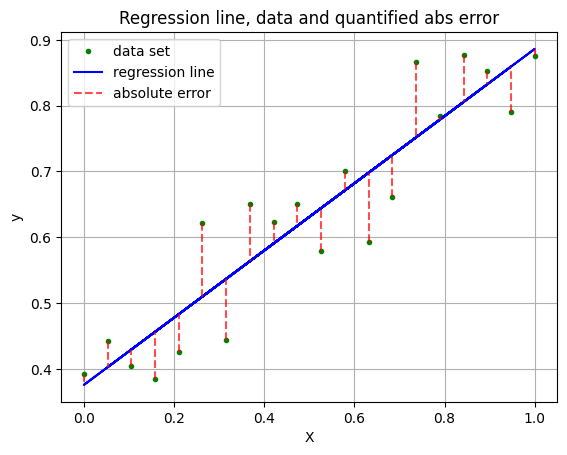

In [36]:
# The absolute error for a data point x with real value y 
# and predicted value yp is defined as: e_abs=(y - y_p)^2

data = np.loadtxt("Et1_Task3.csv", delimiter=",")

X_task3 = np.array(data[:,0]).reshape(-1,1)
y_task3 = np.array(data[:,1])


weights = linreg_weights(X_task3, y_task3)
y_p = linreg_predict(weights, X_task3)
e_abs = np.mean(np.abs(y_task3 - y_p))

print("weights: ", weights)
print("e_abs: ", e_abs)


plt.figure()
plt.title("Regression line, data and quantified abs error")

plt.xlabel("X")
plt.ylabel("y")

plt.plot(X_task3, y_task3,'.', color="g", label="data set")
plt.plot(X_task3, y_p,'-', color="b", label="regression line")

plt.vlines(X_task3.flatten(), y_task3, y_p, colors="red", linestyles="dashed", alpha=0.7, label="absolute error")

plt.legend(loc="best")
plt.grid()

print((y_task3 - y_p)**2)

### 4. Add one data point to the dataset to illustrate how linear regression responds to outliers. Ensure that the absolute error that this new point contributes is no bigger than the sum of absolute errors contributed by all other points.

data length X_task3?  20
data length y_task3?  20
new data length X_task3?  21
new data length y_task3?  21
[2.13082996e-03 1.95401008e-03 2.92249878e-04 2.59539520e-03
 6.60122951e-03 3.32600748e-03 9.03120156e-03 7.21618932e-04
 1.91175023e-03 1.67511177e-03 2.84743494e-03 9.68977313e-03
 6.69334453e-03 2.13996072e-04 4.77550098e-10 1.52336085e-02
 2.94711526e-03 1.56035906e-02 9.27844961e-04 3.65884881e-03
 4.83785133e-02]
The absolute error from this new point: 0.048378513345722476
The sum of absolute errors 0.08805496193239812 contributed by all other points.
The absolute error that this new point contributes 0.048378513345722476 is no bigger than the sum of absolute errors 0.08805496193239812 contributed by all other points.


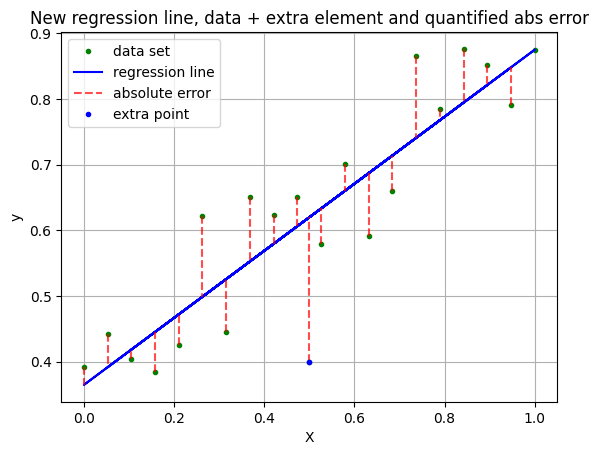

In [ ]:
# Ensure that the absolute error that this new point contributes is no bigger than 
# the sum of absolute errors contributed by all other points.

new_point = [[0.5, 0.4]]

print("data length X_task3? ", len(X_task3))
print("data length y_task3? ", len(y_task3))

new_data = np.append(data, new_point, axis=0)

new_X_task3 = np.array(new_data[:,0]).reshape(-1,1)
new_y_task3 = new_data[:,1]

print("new data length X_task3? ", len(new_X_task3))
print("new data length y_task3? ", len(new_y_task3))

new_weights = linreg_weights(new_X_task3, new_y_task3)
new_y_p = linreg_predict(new_weights, new_X_task3)
np.mean(np.abs(new_y_task3 - new_y_p))


plt.figure()
plt.title("New regression line, data + extra element and quantified abs error")

plt.xlabel("X")
plt.ylabel("y")

plt.plot(new_X_task3, new_y_task3,'.', color="g", label="data set")
plt.plot(new_X_task3, new_y_p,'-', color="b", label="regression line")
plt.vlines(new_X_task3.flatten(), new_y_task3, new_y_p, colors="red", linestyles="dashed", alpha=0.7, label="absolute error")

# suggested addition
plt.plot(new_X_task3[-1], new_y_task3[-1],'.', color="blue", label="extra point")

plt.legend(loc="best")
plt.grid()

print((new_y_task3 - new_y_p)**2)

err_array = (new_y_task3 - new_y_p)**2

sum_new_e_abs = 0
for i in range(len(new_y_task3)-1):
   sum_new_e_abs = sum_new_e_abs + err_array[i]
    

print(f"The absolute error from this new point: {err_array[-1]}")
print(f"The sum of absolute errors {sum_new_e_abs} contributed by all other points.")


# the error from this new point
if sum_new_e_abs > err_array[-1]:
    print(f"The absolute error that this new point contributes {err_array[-1]} is no bigger than the sum of absolute errors {sum_new_e_abs} contributed by all other points.")


### 5. In a new plot, plot the data, the regression line obtained without, and the regression line obtained with the extra data point.

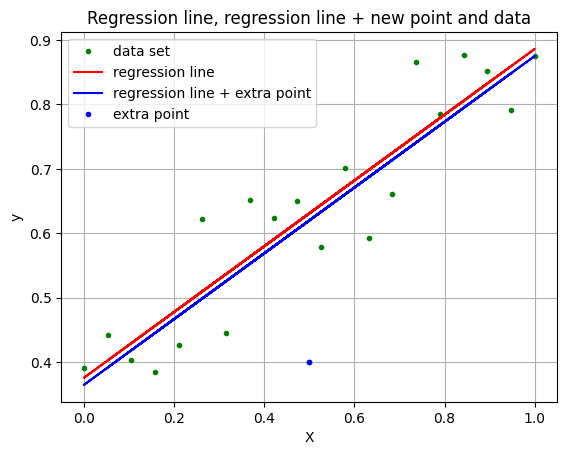

In [38]:
plt.figure()
plt.title("Regression line, regression line + new point and data")

plt.xlabel("X")
plt.ylabel("y")

plt.plot(new_X_task3, new_y_task3,'.', color="g", label="data set")
plt.plot(X_task3, y_p,'-', color="r", label="regression line")
plt.plot(new_X_task3, new_y_p,'-', color="b", label="regression line + extra point")

# suggested addition
plt.plot(new_X_task3[-1], new_y_task3[-1],'.', color="blue", label="extra point")

plt.legend(loc="best")
plt.grid()

### 6.  Answer the following questions (max 100 words per answer):

<b>1. Describe what linear regression tries to achieve in deciding on a regression line/function.</b>

It tries to plot a line with the minimal error across all the points. A line that is as close as possible to all points. The error measure is the mean squared error across all data points between $g(x)$ (the hypothesis) and $y$ (the observed data).


<b>2. Explain why one outlier with an absolute error no bigger than the combined absolute error of all other data points can have such a big impact on the regression line.</b>


I like to imagine this as every point having its own gravity. By placing an extra point, the gravity of that region intensifies and pulls the line closer to the points around that new point. A more technical way to explain it is that due to the nature of the error measure (mean squared error), the final hypothesis over-corrects itself once the next point is added, despite its individual error not being that significant. 



___

# Task 4
## Task 4 code

Below functions may be useful to plot the decision boundary using the model weights

In [ ]:
def get_level_set_y(x,w,value):
    ### Get point x2 (generally thought of as 'y') on the level set or line defined by equation w0+w1x1+w2x2=value  ###
    return (value-w[0]-x*w[1])/w[2]
    
def plot_level_set(plt,X,w,value, label):
    ### Add level set (line where equation for decision boundary has a constant value) defined by w, value and x-coordinates X to the provided plot ### 
    plt.plot(X,[get_level_set_y(X[0],w,value),get_level_set_y(X[1],w,value)],label=label)

def plot_level_sets(plt,X,w,values,labels):
    ### Add level sets (line where equation for decision boundary has a constant value) defined by w, the list values and x-coordinates X to the provided plot ### 
    for value,label in zip(values,labels):
        plot_level_set(plt,X,w,value, label)

## Task 4 Instructions
In this last task we will look at the importance of choosing the right error function for the job in hand.

Use the code provided in the E-tivity notebook under Task 4 to implement a linear classification algorithm trained on dataset Et1_Task4.csv.

1. Add a function implementing the error function used in classification.
2. Add a function implementing linear classification.This should be based on the provided linear regression code. See video 3 (book Learning from Data, page 89).
3. Perform linear classification on the data in Et1_Task4.csv and quantify the performance of your model (on the training data).
4. Plot the output of your classification as a scatter plot with the colour of the data point indicating its class membership. Plot the decision boundary in the same plot using the provided functions.
5. Use sklearn's LogisticRegression model to perform a classification.
6. In a new plot, plot the data, the decision boundary resulting from linear classification, and the decision boundary resulting from linear regresssion.
7. Answer the following questions:
    1. Why is the linear classification decision boundary so far away from the nearest data point from the class -1 (red circles) (200 words max)?
    2. For linear classification how does the error change as correctly classified points are farther away from the decision boundary? Discuss both the case for correctly classified, as well as misclassified points (100 words max).
    3. For logistic regression, how does the error change as points are farther away from the decision boundary? In your answer discuss: 1) the case of correctly and incorrectly classified points with predicted probabilities close to 0.5, 2) correctly and incorrectly classified points with predicted probabilities close to 0 and 1 (100 words max).

## Task 4 Answer

### 1. Add a function implementing the error function used in classification.

In [27]:
# E_in
# in classification, we take the ratio of misclassified points to all points
# as our error
def classification_error(y, y_p):
    mistakes = 0.0
    N = len(y)
    for i in range(N):
        if y[i] != y_p[i]:
            mistakes = mistakes + 1

    return mistakes/N

print(classification_error([-1,-1,-1], [-1,-1,1]))

0.3333333333333333


### 2. Add a function implementing linear classification.This should be based on the provided linear regression code. See video 3 (book Learning from Data, page 89).

In [28]:
# base your function on: linreg_weights(X,y) and linreg_predict(w,X)
def linear_classification(X_input, y_input):

    weights = linreg_weights(X_input, y_input)

    y_p_reg = linreg_predict(weights, X_input)

    y_p = []
    # linear classification uses a hard threshold on the signal s = w.T*x
    for i in range(len(y_p_reg)):
        if y_p_reg[i] < 0:
            y_p = y_p + [-1]
        else:
            y_p = y_p + [1]

    #get_level_set_y(x,w,value)
    return y_p, weights

### 3. Perform linear classification on the data in Et1_Task4.csv and quantify the performance of your model (on the training data).

In [29]:
data = np.loadtxt("Et1_Task4.csv", delimiter=",", skiprows=1)

X_task4 = data[:,0:2]
y_task4  =data[:,2]

print(np.shape(X_task4))
print(np.shape(y_task4))

y_p, linear_classification_weights = linear_classification(X_task4, y_task4)

print("weights: ", linear_classification_weights)
print("classification error in: ", classification_error(y_task4, y_p))

(638, 2)
(638,)
weights:  [-0.6635674   0.11705943  0.06518319]
classification error in:  0.06426332288401254


### 4. Plot the output of your classification as a scatter plot with the colour of the data point indicating its class membership. Plot the decision boundary in the same plot using the provided functions.

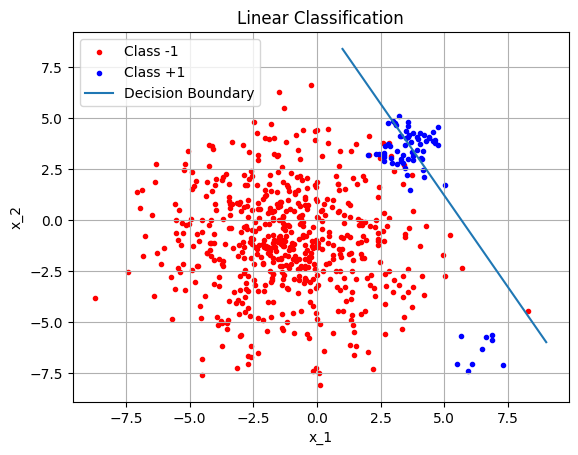

In [30]:
plt.figure()
plt.title("Linear Classification")

plt.xlabel("x_1")
plt.ylabel("x_2")

plt.scatter(X_task4[y_task4 == -1,0], X_task4[y_task4 == -1,1], c='red', marker='.', label="Class -1")
plt.scatter(X_task4[y_task4 == 1,0], X_task4[y_task4 == 1,1], c='blue', marker='.', label="Class +1")
plot_level_sets(plt, [1,9], linear_classification_weights, [0], ["Decision Boundary"])
plt.legend(loc="best")
plt.grid()

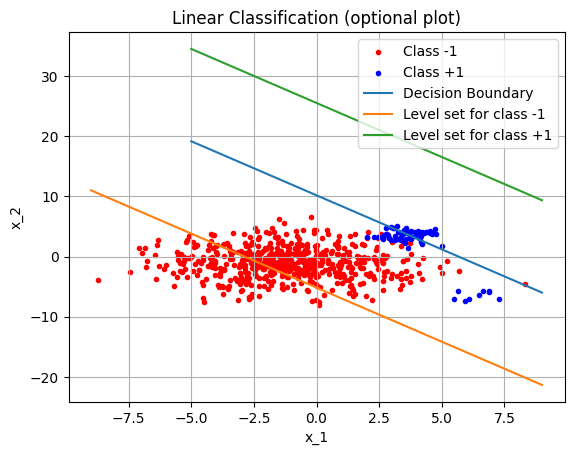

In [31]:
# it may be useful to create further plots to investigate the level sets for +1 and -1 which you can do below.
# This is not a requirement, but may be very informative.
plt.figure()
plt.title("Linear Classification (optional plot)")

plt.xlabel("x_1")
plt.ylabel("x_2")

plt.scatter(X_task4[y_task4 == -1,0], X_task4[y_task4 == -1,1], c='red', marker='.', label="Class -1")
plt.scatter(X_task4[y_task4 == 1,0], X_task4[y_task4 == 1,1], c='blue', marker='.', label="Class +1")
plot_level_sets(plt, [-5,9], linear_classification_weights, [0], ["Decision Boundary"])
plot_level_sets(plt, [-9,9], linear_classification_weights, [-1], ["Level set for class -1"])
plot_level_sets(plt, [-5,9], linear_classification_weights, [1], ["Level set for class +1"])
plt.legend(loc="best")
plt.grid()

### 5. Use sklearn's LogisticRegression model to perform a classification.

[-7.05262838]
[[1.83987626 0.71288803]]
y = 0.71*x^2 + 1.84*x + -7.05
[[ 0.05502546 -0.79487438]
 [ 2.53479825 -1.78721478]
 [-1.57587142  0.92203719]
 ...
 [ 0.83827982 -0.41463078]
 [-5.37392857 -0.75686721]
 [ 4.38920999 -0.67828818]]


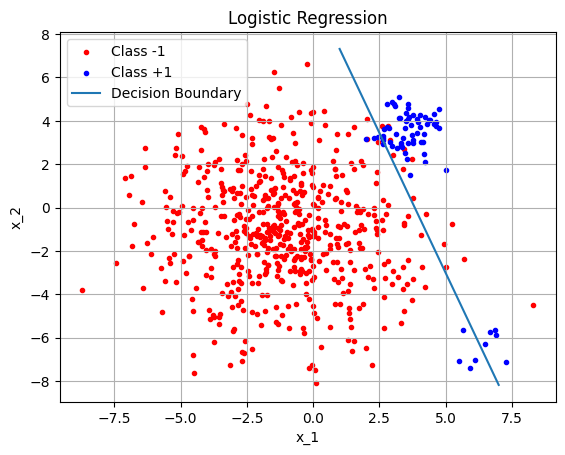

In [ ]:
data = np.loadtxt("Et1_Task4.csv", delimiter=",", skiprows=1)

X_task4 = data[:,0:2]
y_task4  =data[:,2]

classifier = LogisticRegression(random_state=0, solver='lbfgs')

classifier.fit(X_task4, y_task4)

y_p = classifier.predict(X_task4)

classification_error(y_task4, y_p)

print(classifier.intercept_)
print(classifier.coef_)

print(f"y = {classifier.coef_[0][1]:.2f}*x^2 + {classifier.coef_[0][0]:.2f}*x + {classifier.intercept_[0]:.2f}")

print(X_task4*classifier.coef_)

plt.figure()
plt.title("Logistic Regression")

plt.xlabel("x_1")
plt.ylabel("x_2")

plt.scatter(X_task4[y_task4 == -1,0], X_task4[y_task4 == -1,1], c='red', marker='.', label="Class -1")
plt.scatter(X_task4[y_task4 == 1,0], X_task4[y_task4 == 1,1], c='blue', marker='.', label="Class +1")
#(w[0] - x * w[1]) / w[2]
plot_level_sets(plt, [1,7], [classifier.intercept_[0], classifier.coef_[0][0], classifier.coef_[0][1]], [0], ["Decision Boundary"])
plt.legend(loc="best")
plt.grid()

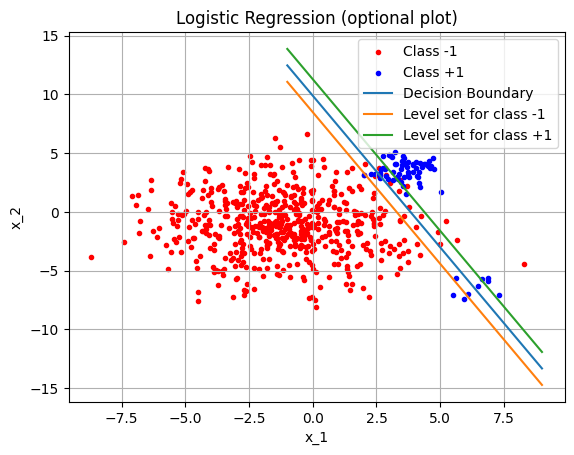

In [33]:
# it may be useful to create further plots to investigate the level sets for +1 and -1 which you can do below.
# This is not a requirement, but may be very informative.
plt.figure()
plt.title("Logistic Regression (optional plot)")

plt.xlabel("x_1")
plt.ylabel("x_2")

plt.scatter(X_task4[y_task4 == -1,0], X_task4[y_task4 == -1,1], c='red', marker='.', label="Class -1")
plt.scatter(X_task4[y_task4 == 1,0], X_task4[y_task4 == 1,1], c='blue', marker='.', label="Class +1")
plot_level_sets(plt, [-1,9], [classifier.intercept_[0], classifier.coef_[0][0], classifier.coef_[0][1]], [0], ["Decision Boundary"])
plot_level_sets(plt, [-1,9], [classifier.intercept_[0], classifier.coef_[0][0], classifier.coef_[0][1]], [-1], ["Level set for class -1"])
plot_level_sets(plt, [-1,9], [classifier.intercept_[0], classifier.coef_[0][0], classifier.coef_[0][1]], [1], ["Level set for class +1"])
plt.legend(loc="best")
plt.grid()

### 6. In a new plot, plot the data, the decision boundary resulting from linear classification, and the decision boundary resulting from logistic regression.

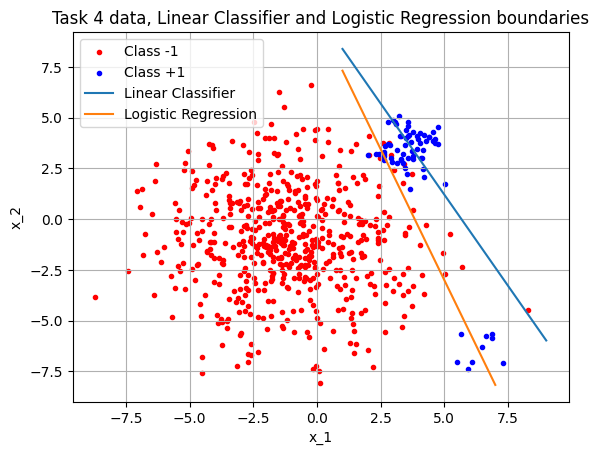

In [34]:
plt.figure()
plt.title("Task 4 data, Linear Classifier and Logistic Regression boundaries")

plt.xlabel("x_1")
plt.ylabel("x_2")

plt.scatter(X_task4[y_task4 == -1,0], X_task4[y_task4 == -1,1], c='red', marker='.', label="Class -1")
plt.scatter(X_task4[y_task4 == 1,0], X_task4[y_task4 == 1,1], c='blue', marker='.', label="Class +1")
plot_level_sets(plt, [1,9], linear_classification_weights, [0], ["Linear Classifier"])
plot_level_sets(plt, [1,7], [classifier.intercept_[0], classifier.coef_[0][0], classifier.coef_[0][1]], [0], ["Logistic Regression"])
plt.legend(loc="best")
plt.grid()


Logistic regression
    - BCE error or log error (training error / estimate weights) / classification error (test error / performance error)
    - soft threshold
    - the decision boundary is h(x) = 0.5 // w^Tx = 0

### 7. Answer the following questions:

<b>1. Why is the linear classification decision boundary so far away from the nearest data point from the class -1 (200 words max)?</b>

This boils down to the mean squared error not being up to the task for linear classification. And I say this because, even though that's the error measure for linear regression, linear classification still uses this error same error to come up with the weights/hypothesis. The difference lies on the fact that for classification, it filters the regression values using a hard threshold by looking at only the sign of what otherwise would be the old $\hat{y} values$. 

If the classes $-1$ and $+1$ were more balanced, the decision boundary from the linear classification would be much better, but as it is evident from the optional plots with the level set lines for both of this classes, the fact that there are so many more points and how close the blue points are to the red ones, it creates this great misclassification for blue points.  

<b>2. For linear classification how does the error change as correctly classified points are farther away from the decision boundary? Discuss both the case for correctly classified, as well as misclassified points (100 words max).</b>

Due to the nature of the classification or activation function, regardless of the magnitude, the only factor that matters from the values extracted using final hypothesis is the signage. This means that correctly classified points incur 0 error and misclassified points incur the same error wether they are close of far away from the decision boundary (hard threshold).

<b>3. For logistic regression, how does the error change as points are farther away from the decision boundary? In your answer discuss: </b>

Binary-Cross Entropy (BCE) is used to assign probabilities to each point of belonging to one class or the other (soft threshold). Important to notice that $classification \hspace{1mm} accuracy = 1 - classification \hspace{1mm} error$.

<b>a. the case of correctly and incorrectly classified points with predicted probabilities close to 0.5, </b>

Around $P \approx 0.5$ is where the activation/sigmoid function is sensitive and points have a level of uncertainty that makes them produce a significant error (misclassified or not).

<b>b. correctly and incorrectly classified points with predicted probabilities close to 0 and 1 (100 words max).</b>

Correctly classified points with probabilities close to 0 or 1 will contribute little to the loss function because of the confidence under which they were classified.  But, if these were misclassified, they will produce a very high error.

# Reflection

<b>1. Clearly describe the changes you have made based on your peers' work and feedback (100 words max).</b>

Reviewing Anthony's task 1 helped me improve my own, I was overestimating the length of my explanation. For task 3, Lori advised me to choose a greater outlier point for section 4. This to create a more illustrative example. And Sara suggested a coloured the additional data point with a different colour from the rest of the dataset to make the graph more understandable and spotted a few errors I had made. For task 4, I also made use for Lori's and Ciaran's submissions to improve my plots, in particular, to better show the difference between classes <code>-1</code> and <code>+1</code>.

<b>2. Summarise your understanding of how the Hoeffding bound, the concept of 'shattering', break points and the growth function inform the VC bound for a binary classifier (400 words max).</b>

The VC bound gave machine learning practitioners a rule of thumb that reduces the question 'how much data is enough data?' to '10 times the amount 
of <i>features</i>'. It feels magical, but the mathematics behind it are genuine and can be tracked all the way back to the <b>Hoeffding bound</b>. It was the foundation to
prove that learning is feasible, as it tells how good our model can be by setting an upper bound. If the worse the binary classifier can perform is acceptable, then 
one can be confident the model is up to the task.

Some conditions: $E_{in}$ must be 'small' and $| E_{in} - E_{out} | \leq \epsilon $. 
The first condition is 'easy', the in-sample error is measured during training and maintaining its quality mainly requires discipline to collect a large and meaningful data set. 
The second condition requires more explanation because the $\epsilon$ hyperparameter could be anything, of course, but a good binary classifier will need a very small $\epsilon$ to stand a chance against new unseen data. 


So, upper limit for the error should be as small as possible, but the Hoeffding bound lost meaning as the size of the data set ($N$) increased due to mathematical proportions. The function $m_H(N)$ was added to the original expression.


The <b>growth function</b> fixed the problem the Hoeffding bound with large $N$ values. By making the use of dichotomies it reduces an infinite set of hypothesis 
to only hypothesis where data points are classified differently. It came as well with its own bound. $m_H(N) \leq 2^{N}$. Finding
the maximum number of dichotomies that a model can have for a specific $N$ requires <b>shattering</b> until a breakpoint is found. To <i>shatter</i> a data set is to realise all possible $2^N$ dichotomies that a binary classifier can create. And a breakpoint is the $N$ value where this is no longer possible.

With those concepts, Vladimir <b>V</b>apnik and Alexey <b>C</b>hervonenkis formulated the dimension VC ($d_{VC} = breakpoint - 1$), that expresses the dimension where the 
model is the must flexible, so it became a metric to measure how complex a model is. It also works better the bigger the data set.
This all boiled down on the VC bound ($4[(2N)^{d_{VC} + 1}]e^{-\frac{1}{8}\epsilon^2 N}$), and from that beast, the rule of thumb came to be.

<b>3. Summarise your understanding of the approximation-generalisation trade-off (200 words max).</b>

Also called the bias-variance trade-off, it's an alternative method of calculating the $E_{out}$ value in machine learning models. Instead of trying to find $E_{out}$ through $E_{in}$ (like in the VC analysis), 
this one is found directly from the final hypothesis. Therefore, this is also another way to say how complex a model is. 

The expected out-of-sample is calculated with the expression: $E_{out} = bias + variance$. Before decomposing these two concepts, it's important to remember that the real $E_{out}$ value will never be known, it's impossible to measure it because the out-of-sample data is infinite, this is why these terms work on <i>expected</i> values. Also, the convention is often tied to an specific $D$ data set, as different data sets will generate different results. Lastly, $\hat{g}(x)$ represents the average hypothesis, assumed to be the best hypothesis that the model can produce. 

Simple models will introduce more <u>bias</u> ($E_x[(\hat{g}(x) - f(x))^2]$), because $\hat{g}(x)$ won't be able to map $f(x)$. 
Complex models will introduce more <u>variance</u> ($E_{x}[E_D(g^D(x) - \hat{g}(x))^2]$), because $\hat{g}(x)$ will encompass more hypothesis, some of them being trivial. The approximation-generalisation trade-off also impacts the Learning curve analysis, as $E_in$ loses meaning and the focus turns to the bias against $E_{out}$.
